In [58]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression


In [59]:
X,y=make_regression(n_samples=200, n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13 ) 

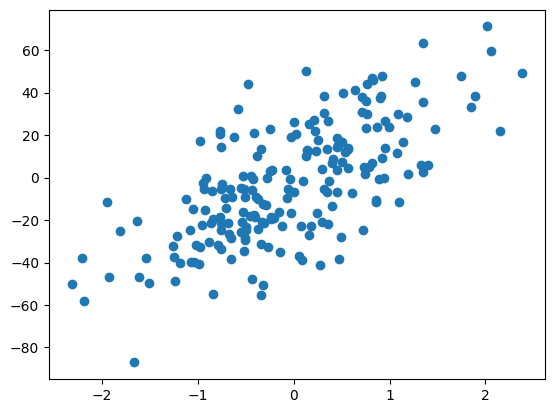

In [60]:
plt.scatter(X,y)

In [61]:
import plotly.graph_objects as go

# Create 3D scatter plot
fig = go.Figure(data=[
    go.Scatter3d(
        x=X[:, 0],  # First feature
        y=X[:, 1] if X.shape[1] > 1 else X[:, 0],  # Second feature (if available)
        z=y,  # Target variable
        mode='markers',
        marker=dict(
            size=5,
            color=y,  # Color points by target value
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Target")
        ),
        name='Data Points'
    )
])

fig.update_layout(
    title="3D Regression Visualization with GD, Newton, and Adam Optimizers",
    scene=dict(
        xaxis_title='Feature 1',
        yaxis_title='Feature 2',
        zaxis_title='Target',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.3)
        )
    ),
    width=900,
    height=700
)

fig.show()


In [62]:
lr=LinearRegression()

In [63]:
lr.fit(X,y)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
print(lr.intercept_)
print(lr.coef_)

-2.02053316517509
[21.44460094]


In [65]:
from sklearn.linear_model import Ridge


-2.0773562142860724
[20.13994678]


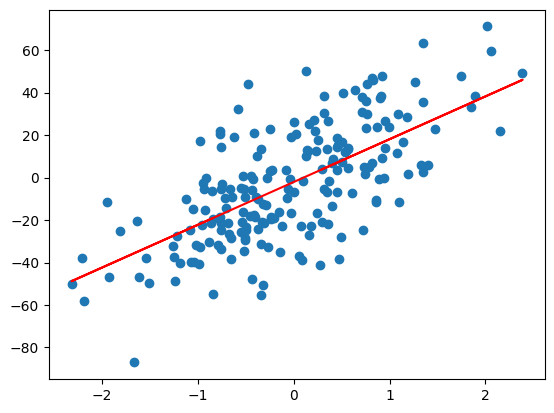

In [66]:

rg=Ridge(alpha=10)
rg.fit(X,y)
print(rg.intercept_)
print(rg.coef_)
plt.scatter(X,y)
plt.plot(X,rg.predict(X),color='red')
plt.show()


-2.908825101605144
[1.0494657]


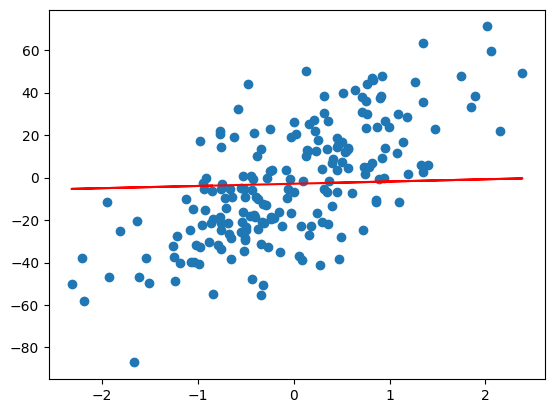

In [67]:
rg1=Ridge(alpha=3000)
rg1.fit(X,y)
print(rg1.intercept_)
print(rg1.coef_)
plt.scatter(X,y)
plt.plot(X,rg1.predict(X),color='red')
plt.show()

In [68]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score


In [69]:
iris=load_iris()
X=iris.data
y=iris.target
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [70]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)  

In [71]:
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
print("Mean Squared Error:",mse)
print("R2 Score:",r2_score(y_test,y_pred))

Mean Squared Error: 0.03711379440797686
R2 Score: 0.9468960016420045


In [72]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Train the model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Create 2x2 subplot for each pair of features
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Features 1 & 2', 'Features 1 & 3', 
                    'Features 1 & 4', 'Features 2 & 3'),
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}],
           [{'type': 'scatter3d'}, {'type': 'scatter3d'}]]
)

feature_pairs = [(0, 1), (0, 2), (0, 3), (1, 2)]

for idx, (f1, f2) in enumerate(feature_pairs):
    row = idx // 2 + 1
    col = idx % 2 + 1
    
    # Training data
    fig.add_trace(go.Scatter3d(
        x=X_train[:, f1],
        y=X_train[:, f2],
        z=y_train,
        mode='markers',
        marker=dict(size=3, color='green'),
        name=f'Train',
        showlegend=(idx == 0)
    ), row=row, col=col)
    
    # Test data
    fig.add_trace(go.Scatter3d(
        x=X_test[:, f1],
        y=X_test[:, f2],
        z=y_test,
        mode='markers',
        marker=dict(size=4, color='red', symbol='diamond'),
        name=f'Test',
        showlegend=(idx == 0)
    ), row=row, col=col)
    
    # Predictions
    fig.add_trace(go.Scatter3d(
        x=X_test[:, f1],
        y=X_test[:, f2],
        z=y_pred,
        mode='markers',
        marker=dict(size=4, color='blue', symbol='x'),
        name=f'Pred',
        showlegend=(idx == 0)
    ), row=row, col=col)

fig.update_layout(
    title_text=f"Multi-Feature Regression Visualization<br>MSE: {mse:.4f} | R²: {r2:.4f}",
    height=900,
    width=1200
)

fig.show()

In [73]:
import plotly.graph_objects as go

fig = go.Figure()

# Perfect prediction line
fig.add_trace(go.Scatter(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    mode='lines',
    name='Perfect Prediction',
    line=dict(color='red', dash='dash', width=2)
))

# Actual vs Predicted
fig.add_trace(go.Scatter(
    x=y_test,
    y=y_pred,
    mode='markers',
    name='Predictions',
    marker=dict(size=8, color='blue', opacity=0.6)
))

fig.update_layout(
    title=f"Predicted vs Actual Values<br>MSE: {mse:.4f} | R²: {r2_score(y_test, y_pred):.4f}",
    xaxis_title='Actual Values',
    yaxis_title='Predicted Values',
    width=800,
    height=600
)

fig.show()